/tmp/ipython-input-3003420088.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Close', data=df, palette="viridis")


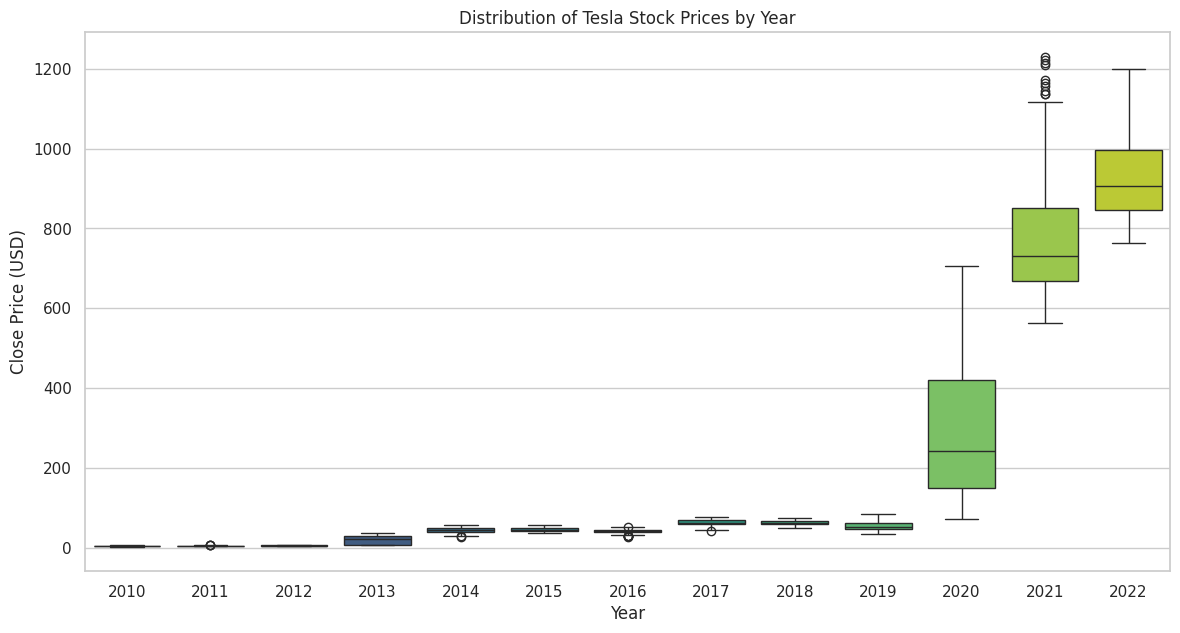

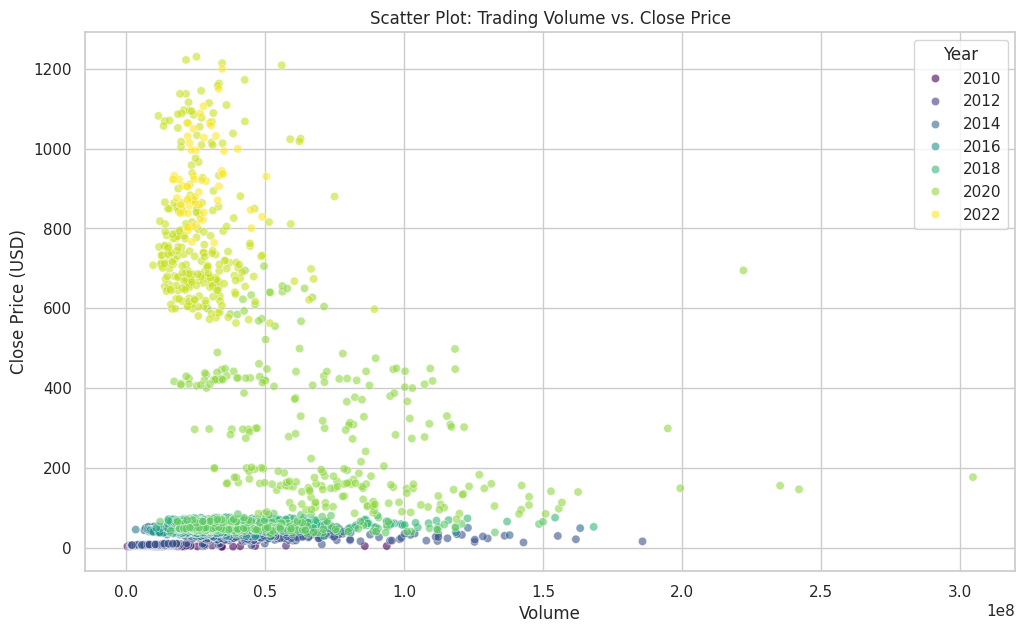

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data-tesla_stock.csv')

# Process Date
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Set plot style
sns.set(style="whitegrid")

# --- 1. Improved Box Plot (By Year) ---
plt.figure(figsize=(14, 7))
# plotting 'Close' price against 'Year' creates a separate box for each year
sns.boxplot(x='Year', y='Close', data=df, palette="viridis")
plt.title('Distribution of Tesla Stock Prices by Year')
plt.ylabel('Close Price (USD)')
plt.xlabel('Year')
plt.show()

# --- 2. Scatter Plot (Volume vs Close, Colored by Year) ---
plt.figure(figsize=(12, 7))
# The 'hue' parameter adds the color coding by Year
sns.scatterplot(x=df['Volume'], y=df['Close'], hue=df['Year'], palette="viridis", alpha=0.6)
plt.title('Scatter Plot: Trading Volume vs. Close Price')
plt.xlabel('Volume')
plt.ylabel('Close Price (USD)')
plt.legend(title='Year')
plt.show()

/tmp/ipython-input-1499932378.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='race/ethnicity', y='math percentage', data=df, order=order, palette="Set2")


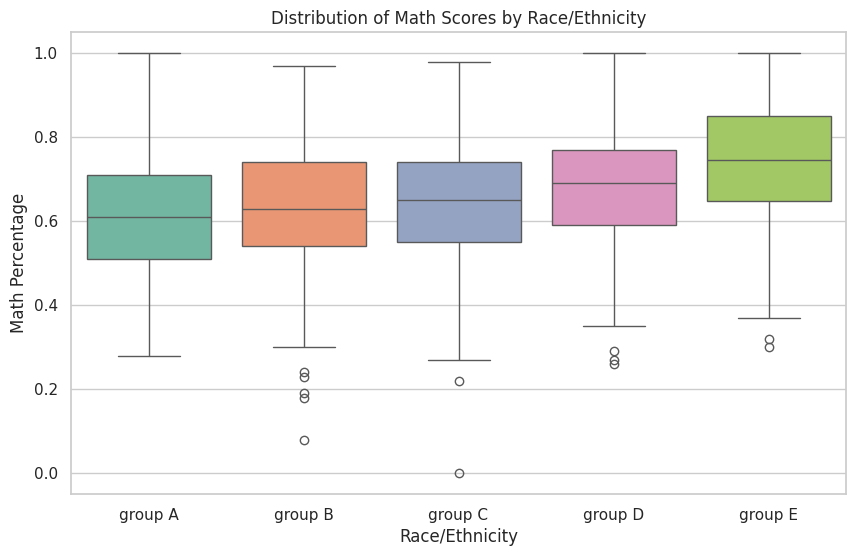

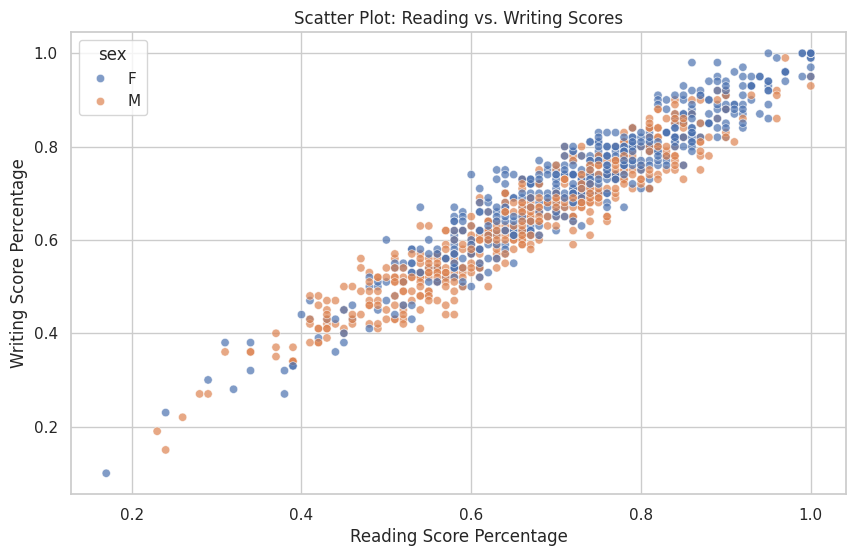

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('data-student_performance.csv')

# Set visual style
sns.set(style="whitegrid")

# --- PLOT 1: Box Plot (Math Score by Race/Ethnicity) ---
plt.figure(figsize=(10, 6))
# We sort the unique values to ensure the groups appear in order (A, B, C...)
order = sorted(df['race/ethnicity'].unique())
sns.boxplot(x='race/ethnicity', y='math percentage', data=df, order=order, palette="Set2")
plt.title('Distribution of Math Scores by Race/Ethnicity')
plt.ylabel('Math Percentage')
plt.xlabel('Race/Ethnicity')
plt.show()

# --- PLOT 2: Scatter Plot (Reading vs Writing) ---
plt.figure(figsize=(10, 6))
# Hue='sex' adds color coding to see gender differences
sns.scatterplot(
    x='reading score percentage',
    y='writing score percentage',
    data=df,
    hue='sex',
    alpha=0.7,
    palette="deep"
)
plt.title('Scatter Plot: Reading vs. Writing Scores')
plt.xlabel('Reading Score Percentage')
plt.ylabel('Writing Score Percentage')
plt.show()

/tmp/ipython-input-1003830587.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='NoShow', y='Age', data=df, palette="pastel")


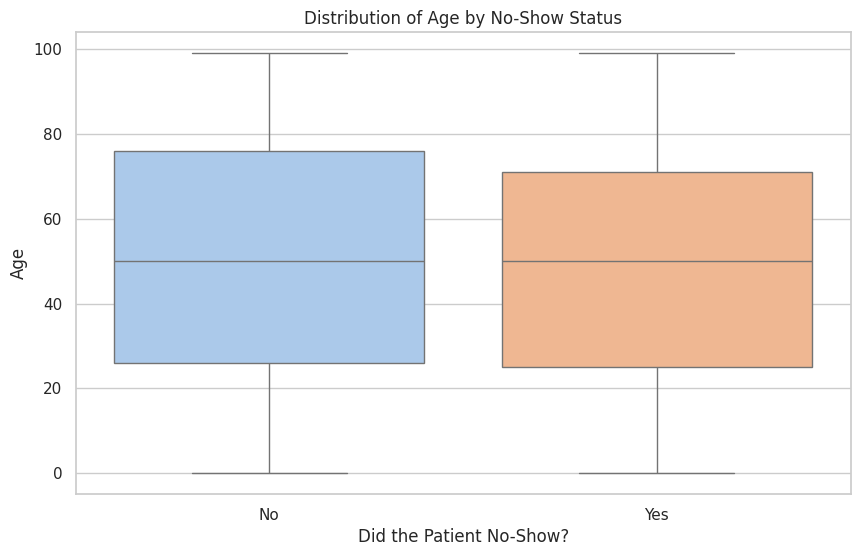

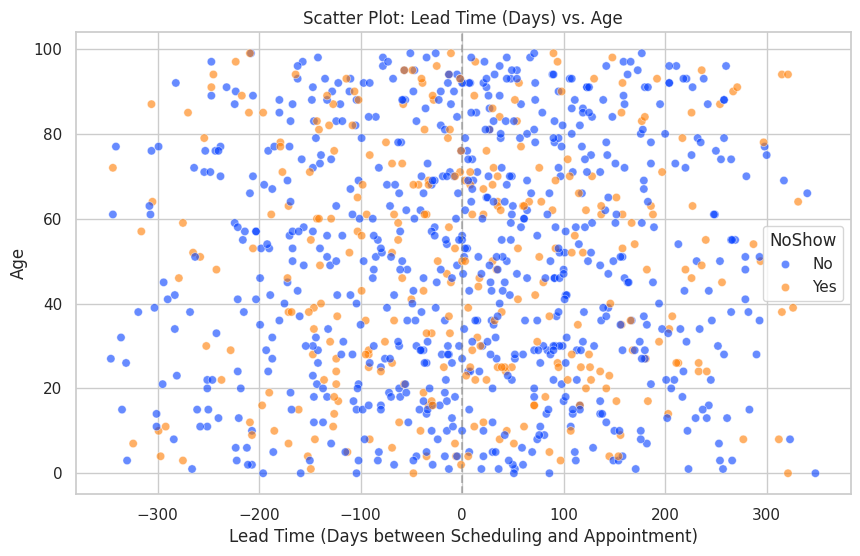

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('data-fitness_tracker_data.csv')

# 2. Preprocessing
# Convert date columns to datetime objects
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Create 'LeadTime' feature: The difference in days between appointment and scheduling
df['LeadTime'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Set visual style
sns.set(style="whitegrid")

# --- PLOT 1: Box Plot (Age by No-Show) ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='NoShow', y='Age', data=df, palette="pastel")
plt.title('Distribution of Age by No-Show Status')
plt.xlabel('Did the Patient No-Show?')
plt.ylabel('Age')
plt.show()

# --- PLOT 2: Scatter Plot (Lead Time vs Age) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='LeadTime',
    y='Age',
    data=df,
    hue='NoShow',
    alpha=0.6,
    palette="bright"
)
plt.title('Scatter Plot: Lead Time (Days) vs. Age')
plt.xlabel('Lead Time (Days between Scheduling and Appointment)')
plt.ylabel('Age')
# Add a vertical line at 0 to distinguish past vs future scheduling
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.show()

/tmp/ipython-input-2538316228.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='ExportValue', data=df_melted, palette="Set3")


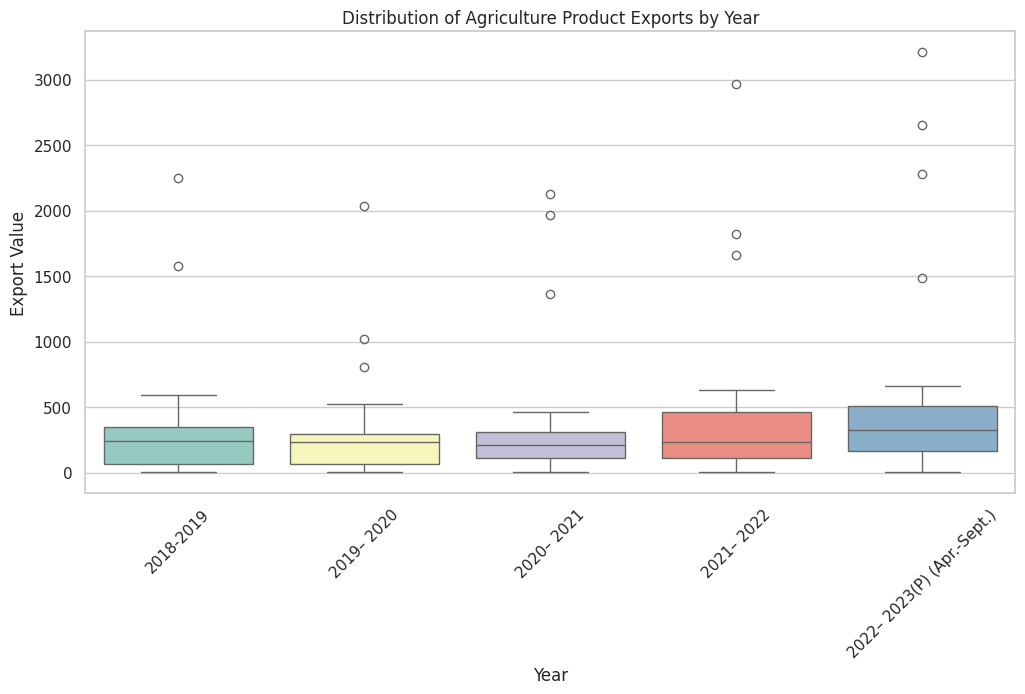

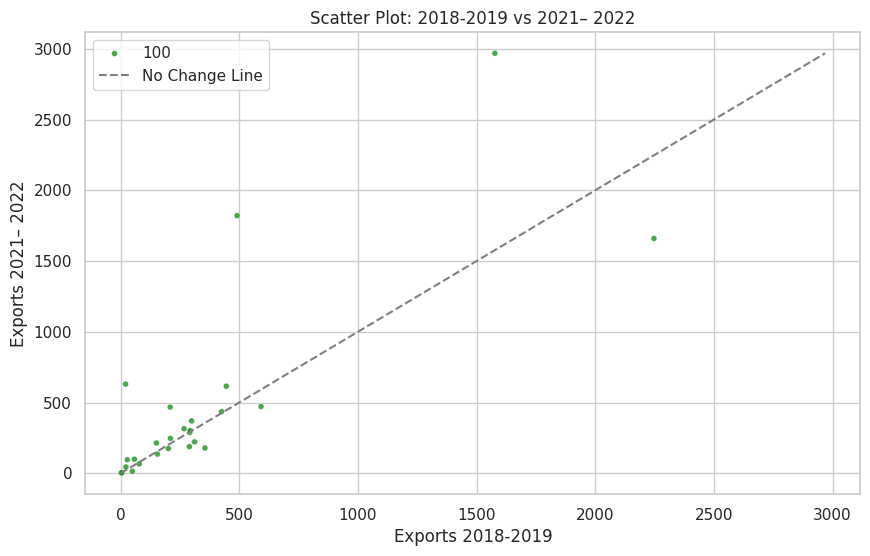

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Note: The actual header is on the second row (header=1) based on file inspection
df = pd.read_csv('data-agriculture_products_exports.csv', header=1)

# 2. Data Cleaning
# Drop the serial number column if it exists
if 'S.No.' in df.columns:
    df = df.drop('S.No.', axis=1)

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Identify year columns (excluding 'Commodity' and index columns)
# We assume columns starting with '20' are year columns
year_cols = [col for col in df.columns if col.startswith('20')]

# Function to clean currency strings (e.g., "1, 659. 60" -> 1659.60)
def clean_currency(x):
    if isinstance(x, str):
        x = x.replace(',', '')  # Remove commas
        x = x.replace(' ', '')  # Remove spaces
        return float(x)
    return x

# Apply cleaning to all year columns
for col in year_cols:
    df[col] = df[col].apply(clean_currency)

# Set visual style
sns.set(style="whitegrid")

# --- PLOT 1: Box Plot (Distribution by Year) ---
# Melt data to long format for box plotting
df_melted = df.melt(id_vars='Commodity', value_vars=year_cols, var_name='Year', value_name='ExportValue')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='ExportValue', data=df_melted, palette="Set3")
plt.title('Distribution of Agriculture Product Exports by Year')
plt.ylabel('Export Value')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.show()

# --- PLOT 2: Scatter Plot (2018-2019 vs 2021-2022) ---
# Compare the first year vs a recent full year
col_start = year_cols[0]   # 2018-2019
col_end = year_cols[-2]    # 2021-2022 (Avoiding the partial 2022-23 col)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[col_start], y=df[col_end], size=100, alpha=0.7, color='green')
plt.title(f'Scatter Plot: {col_start} vs {col_end}')
plt.xlabel(f'Exports {col_start}')
plt.ylabel(f'Exports {col_end}')

# Add a diagonal "No Change" line
max_val = max(df[col_start].max(), df[col_end].max())
plt.plot([0, max_val], [0, max_val], '--', color='grey', label='No Change Line')
plt.legend()
plt.show()